<a href="https://colab.research.google.com/github/aydanali/ECON3916-Stats-and-ML/blob/main/Project1/StatsML_Project1_Phase4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import statsmodels.formula.api as smf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

In [ ]:
from google.colab import drive
drive.mount('/content/gdrive')

df_raw = pd.read_csv('gdrive/My Drive/callbacks_experiement_data.csv')
df = df_raw.fillna(0)

df

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).


,job_ad_id,job_city,job_industry,job_type,job_fed_contractor,job_equal_opp_employer,job_ownership,job_req_any,job_req_communication,job_req_education,...,honors,worked_during_school,years_experience,computer_skills,special_skills,volunteer,military,employment_holes,has_email_address,resume_quality
0,384,Chicago,manufacturing,supervisor,0.0,1,unknown,1,0,0,...,0,0,6,1,0,0,0,1,0,low
1,384,Chicago,manufacturing,supervisor,0.0,1,unknown,1,0,0,...,0,1,6,1,0,1,1,0,1,high
2,384,Chicago,manufacturing,supervisor,0.0,1,unknown,1,0,0,...,0,1,6,1,0,0,0,0,0,low
3,384,Chicago,manufacturing,supervisor,0.0,1,unknown,1,0,0,...,0,0,6,1,1,1,0,1,1,high
4,385,Chicago,other_service,secretary,0.0,1,nonprofit,1,0,0,...,0,1,22,1,0,0,0,0,1,high
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4865,1344,Boston,finance_insurance_real_estate,secretary,0.0,0,private,1,0,0,...,0,0,1,1,1,0,0,1,0,low
4866,382,Boston,other_service,manager,0.0,0,unknown,0,0,0,...,0,1,6,1,0,0,0,0,0,low
4867,382,Boston,other_service,manager,0.0,0,unknown,0,0,0,...,0,1,8,1,0,1,0,0,1,high
4868,382,Boston,other_service,manager,0.0,0,unknown,0,0,0,...,0,1,2,1,0,1,1,0,1,high


In [ ]:
non_binary = []
for i in df:
  if df[i].unique().size > 2:
    non_binary.append(i)

df_descript = df[non_binary]
df_descript['job_req_min_experience'] = pd.to_numeric(df['job_req_min_experience'], errors='coerce')

df_descript[non_binary].describe()

/tmp/ipykernel_196/1333696700.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_descript['job_req_min_experience'] = pd.to_numeric(df['job_req_min_experience'], errors='coerce')


,job_ad_id,job_req_min_experience,years_college,years_experience
count,4870.000000,3806.000000,4870.000000,4870.000000
mean,651.777823,0.811876,3.618480,7.842916
std,388.690698,1.584858,0.714997,5.044612
min,1.000000,0.000000,0.000000,1.000000
25%,306.250000,0.000000,3.000000,5.000000
50%,647.000000,0.000000,4.000000,6.000000
75%,979.750000,1.000000,4.000000,9.000000
max,1344.000000,10.000000,4.000000,44.000000


<Axes: >

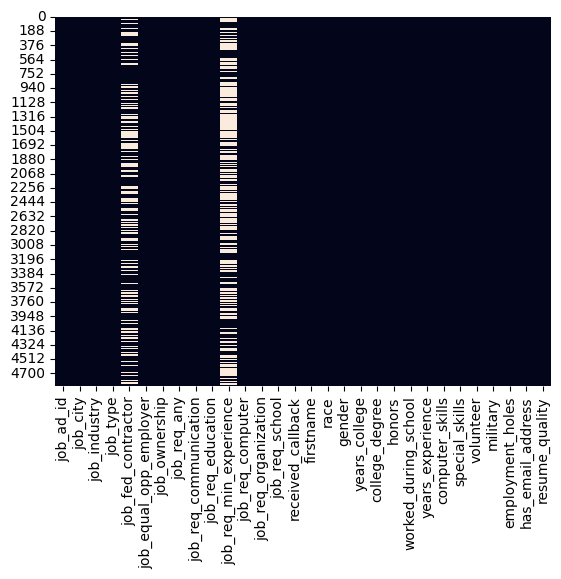

In [ ]:
sns.heatmap(df_raw.isnull(), cbar=False)

[Text(0, 0, '0.064'), Text(0, 0, '0.097')]

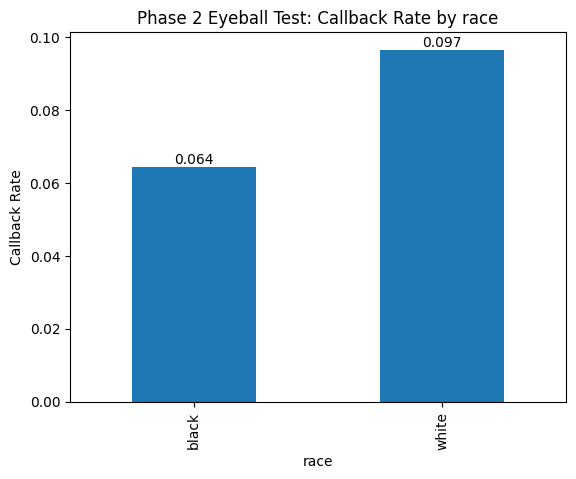

In [ ]:
callback_rates = df.groupby('race')['received_callback'].mean()
callback_rates.plot(kind='bar')
ax = callback_rates.plot(kind='bar')

plt.title('Phase 2 Eyeball Test: Callback Rate by race')
plt.ylabel('Callback Rate')
ax.bar_label(ax.containers[0], fmt='%.3f')

In [ ]:
formula_1 = 'received_callback ~ race + resume_quality + computer_skills + years_experience + college_degree'

model_1 = smf.probit(formula=formula_1, data=df).fit(cov_type='cluster', cov_kwds={'groups': df['job_ad_id']})

print(model_1.summary())

Optimization terminated successfully.
         Current function value: 0.275870
         Iterations 6
                          Probit Regression Results                           
Dep. Variable:      received_callback   No. Observations:                 4870
Model:                         Probit   Df Residuals:                     4864
Method:                           MLE   Df Model:                            5
Date:                Thu, 26 Mar 2026   Pseudo R-squ.:                 0.01465
Time:                        08:41:58   Log-Likelihood:                -1343.5
converged:                       True   LL-Null:                       -1363.5
Covariance Type:              cluster   LLR p-value:                 1.532e-07
                            coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Intercept                -1.4894      0.116    -12.862      0.000      -1.716      -1.

In [ ]:
me = model_1.get_margeff()
print(me.summary())

       Probit Marginal Effects       
Dep. Variable:      received_callback
Method:                          dydx
At:                           overall
                           dy/dx    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------
race[T.white]             0.0314      0.006      5.029      0.000       0.019       0.044
resume_quality[T.low]    -0.0149      0.007     -2.109      0.035      -0.029      -0.001
computer_skills          -0.0201      0.011     -1.795      0.073      -0.042       0.002
years_experience          0.0027      0.001      3.306      0.001       0.001       0.004
college_degree           -0.0041      0.009     -0.435      0.664      -0.022       0.014


In [ ]:
formula_race = 'received_callback ~ resume_quality + computer_skills + years_experience + college_degree'

model_white = smf.probit(formula=formula_race, data=df[df['race'] == 'white']
                         ).fit(cov_type='cluster', cov_kwds={'groups': df[df['race'] == 'white']['job_ad_id']})

print(model_white.summary())

Optimization terminated successfully.
         Current function value: 0.313911
         Iterations 6
                          Probit Regression Results                           
Dep. Variable:      received_callback   No. Observations:                 2435
Model:                         Probit   Df Residuals:                     2430
Method:                           MLE   Df Model:                            4
Date:                Thu, 26 Mar 2026   Pseudo R-squ.:                 0.01082
Time:                        08:04:36   Log-Likelihood:                -764.37
converged:                       True   LL-Null:                       -772.73
Covariance Type:              cluster   LLR p-value:                  0.002188
                            coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Intercept                -1.1501      0.134     -8.555      0.000      -1.414      -0.

In [ ]:
model_black = smf.probit(formula=formula_race, data=df[df['race'] == 'black']
                         ).fit(cov_type='cluster', cov_kwds={'groups': df[df['race'] == 'black']['job_ad_id']})

print(model_black.summary())

Optimization terminated successfully.
         Current function value: 0.237223
         Iterations 6
                          Probit Regression Results                           
Dep. Variable:      received_callback   No. Observations:                 2435
Model:                         Probit   Df Residuals:                     2430
Method:                           MLE   Df Model:                            4
Date:                Thu, 26 Mar 2026   Pseudo R-squ.:                0.007894
Time:                        08:07:04   Log-Likelihood:                -577.64
converged:                       True   LL-Null:                       -582.23
Covariance Type:              cluster   LLR p-value:                   0.05646
                            coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Intercept                -1.6724      0.155    -10.809      0.000      -1.976      -1.

In [ ]:
me = model_white.get_margeff()
print(me.summary())

       Probit Marginal Effects       
Dep. Variable:      received_callback
Method:                          dydx
At:                           overall
                           dy/dx    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------
resume_quality[T.low]    -0.0275      0.010     -2.780      0.005      -0.047      -0.008
computer_skills          -0.0345      0.016     -2.188      0.029      -0.065      -0.004
years_experience          0.0028      0.001      2.408      0.016       0.001       0.005
college_degree           -0.0115      0.013     -0.881      0.378      -0.037       0.014


In [ ]:
me = model_black.get_margeff()
print(me.summary())

       Probit Marginal Effects       
Dep. Variable:      received_callback
Method:                          dydx
At:                           overall
                           dy/dx    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------
resume_quality[T.low]    -0.0026      0.009     -0.305      0.760      -0.019       0.014
computer_skills          -0.0049      0.014     -0.357      0.721      -0.032       0.022
years_experience          0.0027      0.001      2.775      0.006       0.001       0.005
college_degree            0.0032      0.011      0.295      0.768      -0.018       0.025


In [ ]:
formula_robust = ['received_callback ~ race',
                  'received_callback ~ race + resume_quality',
                  'received_callback ~ race + resume_quality + computer_skills',
                  'received_callback ~ race + resume_quality + computer_skills + years_experience',
                  'received_callback ~ race + resume_quality + computer_skills + years_experience + college_degree']

for i in formula_robust:
  model_robust = smf.probit(formula=i, data=df).fit(cov_type='cluster', cov_kwds={'groups': df['job_ad_id']})
  print(model_robust.summary())

Optimization terminated successfully.
         Current function value: 0.278228
         Iterations 6
                          Probit Regression Results                           
Dep. Variable:      received_callback   No. Observations:                 4870
Model:                         Probit   Df Residuals:                     4868
Method:                           MLE   Df Model:                            1
Date:                Thu, 26 Mar 2026   Pseudo R-squ.:                0.006228
Time:                        08:50:08   Log-Likelihood:                -1355.0
converged:                       True   LL-Null:                       -1363.5
Covariance Type:              cluster   LLR p-value:                 3.771e-05
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept        -1.5182      0.046    -33.082      0.000      -1.608      -1.428
race[T.white]     0.

In [ ]:
predicted = model_1.predict()
actual = df['received_callback'].values
pearson_residual = (actual - predicted) / np.sqrt(predicted * (1 - predicted))

Text(0.5, 1.0, 'Fitted Probability vs Pearson Residuals')

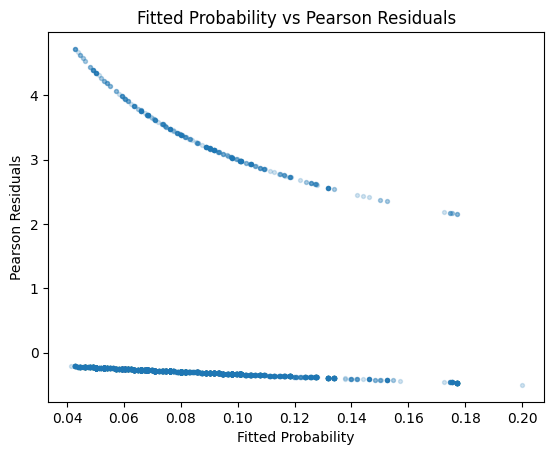

In [ ]:
plt.scatter(predicted, pearson_residual, alpha=0.2, s=8)
plt.xlabel('Fitted Probability')
plt.ylabel('Pearson Residuals')
plt.title('Fitted Probability vs Pearson Residuals')

Text(0.5, 1.0, 'Years of Experience vs Pearson Residuals')

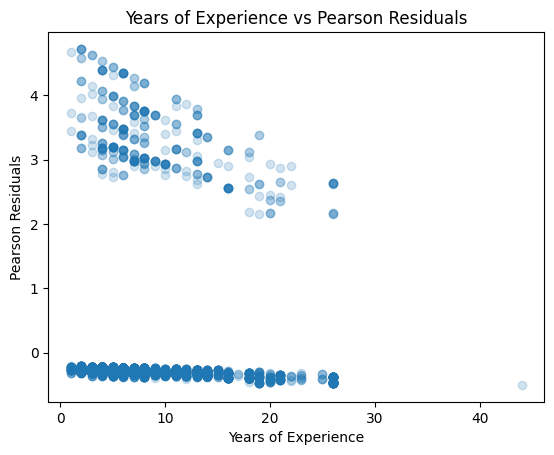

In [ ]:
plt.scatter(df['years_experience'], pearson_residual,
                alpha=0.2)
plt.xlabel('Years of Experience')
plt.ylabel('Pearson Residuals')
plt.title('Years of Experience vs Pearson Residuals')

/tmp/ipykernel_196/3887392638.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([white_residual, black_residual],


Text(0.5, 1.0, 'Residuals by Race')

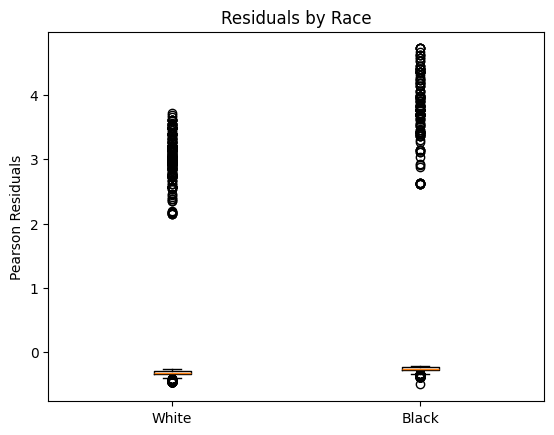

In [ ]:
white_residual = pearson_residual[df['race'] == 'white']
black_residual = pearson_residual[df['race'] == 'black']
plt.boxplot([white_residual, black_residual],
                labels=['White', 'Black'])
plt.ylabel('Pearson Residuals')
plt.title('Residuals by Race')